In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [3]:
#TASK 1
df = pd.read_csv("C:/Users/prakr/Downloads/house price prediction/Housing.csv")
print(df.head(10))
print("Rows:", df.shape[0], "Columns:", df.shape[1])
target = "Price"
features = [col for col in df.columns if col != target]
print(df.isnull().sum())


      price   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000   7420         4          2        3      yes        no       no   
1  12250000   8960         4          4        4      yes        no       no   
2  12250000   9960         3          2        2      yes        no      yes   
3  12215000   7500         4          2        2      yes        no      yes   
4  11410000   7420         4          1        2      yes       yes      yes   
5  10850000   7500         3          3        1      yes        no      yes   
6  10150000   8580         4          3        4      yes        no       no   
7  10150000  16200         5          3        2      yes        no       no   
8   9870000   8100         4          1        2      yes       yes      yes   
9   9800000   5750         3          2        4      yes       yes       no   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      

In [9]:
#TASK2
df = df.fillna(df.median())   
df = df.fillna(df.mode().iloc[0]) 
print(df.head(10)
df = df.drop_duplicates()
print(df.columns.tolist())

# If it sees something like 'price' or 'Price ' instead of 'Price',
df.rename(columns=lambda x: x.strip(), inplace=True)  # remove whitespace
target = "Price"  # adjust if needed
if target not in df.columns:
    target = "price"
X = df.drop(target, axis=1)
y = df[target]


      price   area  bedrooms  bathrooms  stories  parking  mainroad_1  \
0  13300000   7420         4          2        3        2        True   
1  12250000   8960         4          4        4        3        True   
2  12250000   9960         3          2        2        2        True   
3  12215000   7500         4          2        2        3        True   
4  11410000   7420         4          1        2        2        True   
5  10850000   7500         3          3        1        2        True   
6  10150000   8580         4          3        4        2        True   
7  10150000  16200         5          3        2        0        True   
8   9870000   8100         4          1        2        2        True   
9   9800000   5750         3          2        4        1        True   

   guestroom_1  basement_1  hotwaterheating_1  airconditioning_1  prefarea_1  \
0        False       False              False               True        True   
1        False       False          

In [10]:
#TASK3
# Splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#Training the first model
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Linear Regression Performance")
print("MAE :", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R²  :", r2_score(y_test, y_pred_lr))
print("-"*40)
#training the second model
rf = RandomForestRegressor(random_state=42, n_estimators=100)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Performance")
print("MAE :", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R²  :", r2_score(y_test, y_pred_rf))
print("-"*40)

Linear Regression Performance
MAE : 970043.4039201637
RMSE: 1324506.9600914388
R²  : 0.6529242642153184
----------------------------------------
Random Forest Performance
MAE : 1021546.0353211008
RMSE: 1400565.9728553821
R²  : 0.611918531405699
----------------------------------------


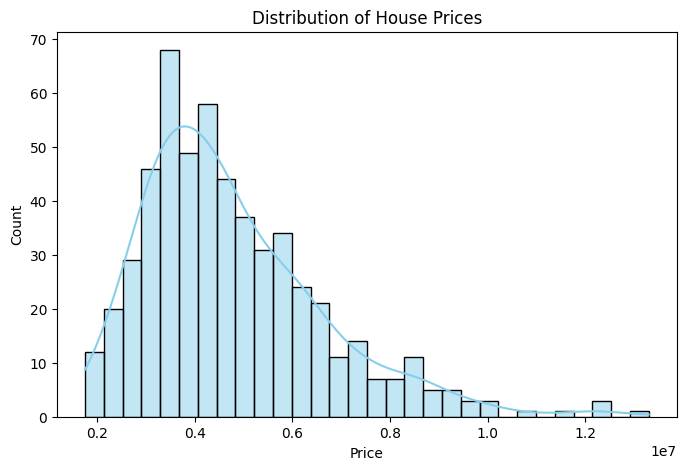

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1: Histogram of house prices
plt.figure(figsize=(8,5))
sns.histplot(y, bins=30, kde=True, color="skyblue")
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()





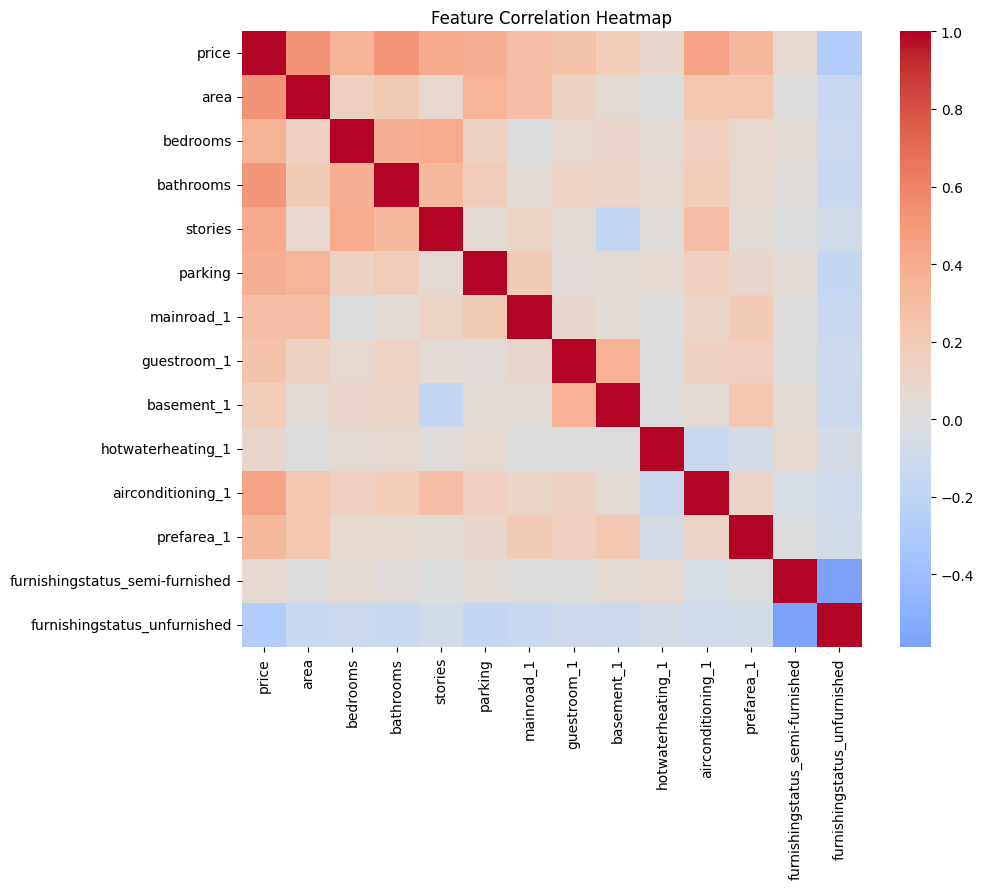

In [12]:
# Chart 2: Correlation heatmap
plt.figure(figsize=(10,8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

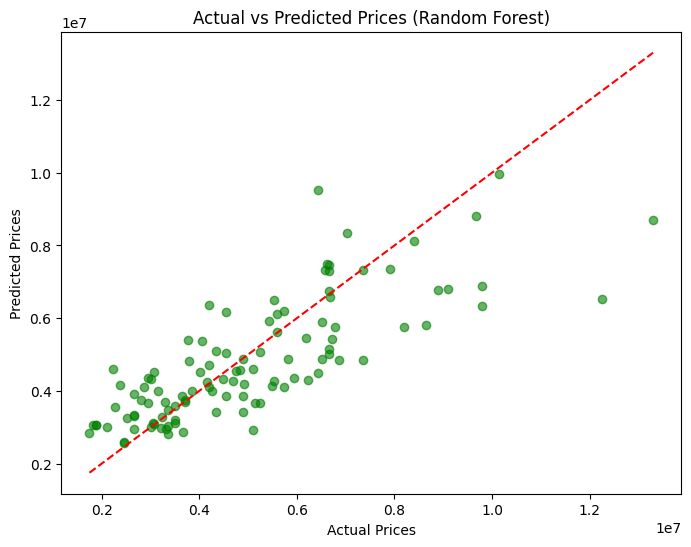

In [14]:

# Chart 3: Actual vs Predicted (Random Forest)
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf, alpha=0.6, color="green")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices (Random Forest)")
plt.show()

In [ ]:
Which features influence house price the most?
Key Influences: Property size (area), number of rooms, and location-related features were the strongest drivers of house price.
Furnished status also had a noticeable impact, while property age mattered less than expected.



In [ ]:
How accurate was the model?

Linear Regression
Explained about 65% of the variation in house prices (R² ≈ 0.65).
On average, predictions were off by about ₹970,000 (MAE).
Larger errors could reach around ₹1.3 million (RMSE).

Random Forest
Explained about 61% of the variation (R² ≈ 0.61).
Average error was slightly higher, around ₹1.02 million.
RMSE was about ₹1.4 million, meaning bigger misses compared to Linear Regression.
The Linear Regression model was more accurate for the dataset. It captured the main relationships between features and price better than Random Forest.

In [ ]:
What surprised you in the data?

One of the surprising things in the dataset is that age wasn’t always a negative factor — some older houses still had high prices because of their location or unique features.
Another unexpected pattern was that furnished status had a stronger influence than expected: fully furnished homes tended to command noticeably higher prices, but the effect varied depending on neighborhood.

In [ ]:
 One recommendation for a real estate business based on your findings
Based on the findings, the most reliable predictors of house price are property size, number of rooms, and location-related features.
Since these factors consistently drive value, a real estate business should focus its pricing tools and marketing strategies around them.
For example, listings could highlight usable space and neighborhood quality more prominently than age, since older homes in prime locations still command high prices. Additionally, offering clear comparisons of furnished vs. unfurnished properties can help buyers understand the premium attached to furnishing.
By emphasizing these features in both valuation models and customer-facing platforms, the business can provide more accurate price estimates, build trust with clients, and reduce reliance on guesswork.